In [1]:
import pandas as pd
import numpy as np

  # Import libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

  # Import scikit-learn tools for preprocessing, modeling, and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
      confusion_matrix,
      classification_report,
      accuracy_score,
      precision_score,
      recall_score,
      f1_score
  )

# Display plots inside the notebook
%matplotlib inline

# Set a clean visual style
sns.set(style="whitegrid")

In [2]:
# Define column names based on the UCI Credit Approval dataset documentation
columns = [
      "A1", "A2", "A3", "A4", "A5", "A6", "A7", "A8",
      "A9", "A10", "A11", "A12", "A13", "A14", "A15", "A16"
  ]

# Load the dataset
df = pd.read_csv("creditApproval/crx.data", header=None, names=columns)

  # Display the first five rows
df.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,00202,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,00043,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,00280,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,00100,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,00120,0,+


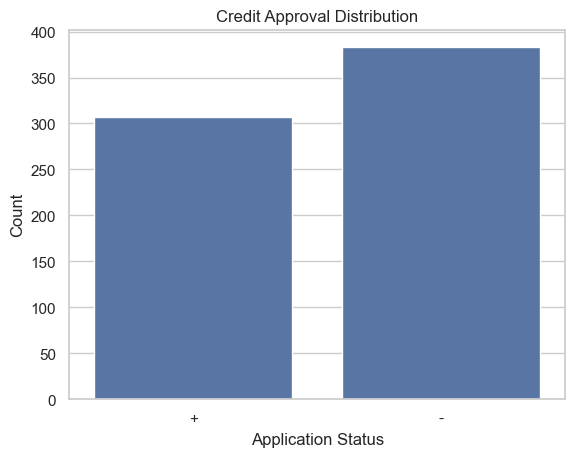

In [3]:
  # Check dataset shape
df.shape
  # Check the target variable distribution
df["A16"].value_counts()
sns.countplot(data=df, x="A16")
plt.title("Credit Approval Distribution")
plt.xlabel("Application Status")
plt.ylabel("Count")
plt.show()

In [4]:
# Replace question marks with NaN
df = df.replace("?", np.nan)

# Define numeric and categorical columns
numeric_columns = ["A2", "A3", "A8", "A11", "A14", "A15"]

categorical_columns = [
    "A1", "A4", "A5", "A6", "A7",
    "A9", "A10", "A12", "A13"
  ]

# Convert numeric columns stored as text into numeric values
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

  # Check missing values before cleaning
print("Missing values before cleaning:")
print(df.isna().sum())

Missing values before cleaning:
A1     12
A2     12
A3      0
A4      6
A5      6
A6      9
A7      9
A8      0
A9      0
A10     0
A11     0
A12     0
A13     0
A14    13
A15     0
A16     0
dtype: int64


In [5]:
# Fill missing numeric values with the median
for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

# Fill missing categorical values with the mode
for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

# Check missing values after cleaning
print("Missing values after cleaning:")
print(df.isna().sum())

Missing values after cleaning:
A1     0
A2     0
A3     0
A4     0
A5     0
A6     0
A7     0
A8     0
A9     0
A10    0
A11    0
A12    0
A13    0
A14    0
A15    0
A16    0
dtype: int64


In [6]:
# Separate features from target variable
X = df.drop("A16", axis=1)

# Convert target variable to binary values
# + = approved, - = rejected
y = df["A16"].map({"+": 1, "-": 0})

In [7]:
# Confirm feature and target dimensions
X.shape, y.shape

((690, 15), (690,))

In [8]:
# Check target class distribution
y.value_counts()

A16
0    383
1    307
Name: count, dtype: int64

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
      X,
      y,
      test_size=0.2,
      random_state=42,
      stratify=y
  )

In [10]:
# Check the size of each split
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((552, 15), (138, 15), (552,), (138,))

In [11]:
y_train.value_counts()

A16
0    306
1    246
Name: count, dtype: int64

In [12]:
y_test.value_counts()

A16
0    77
1    61
Name: count, dtype: int64

In [13]:
# Identify numeric and categorical columns
numeric_columns = ["A2", "A3", "A8", "A11", "A14", "A15"]

categorical_columns = [
      "A1", "A4", "A5", "A6", "A7",
      "A9", "A10", "A12", "A13"
  ]

  # Create preprocessing transformer
preprocessor = ColumnTransformer(
      transformers=[
          ("num", StandardScaler(), numeric_columns),
          ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
      ]
  )

In [14]:
# Create a pipeline with preprocessing and logistic regression model
model = Pipeline(
      steps=[
          ("preprocessor", preprocessor),
          ("classifier", LogisticRegression(max_iter=1000, random_state=42))
      ]
  )

  # Train the model
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [15]:
# Check model training score
model.score(X_train, y_train)

0.8695652173913043

In [16]:
# Make predictions on the test set
y_pred = model.predict(X_test)

In [17]:
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

metrics = pd.DataFrame({
      "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
      "Score": [accuracy, precision, recall, f1]
  })
metrics

,Metric,Score
0,Accuracy,0.869565
1,Precision,0.852459
2,Recall,0.852459
3,F1 Score,0.852459


In [18]:
# Display detailed classification report
report = classification_report(y_test, y_pred, target_names=["Rejected", "Approved"])
print(report)

              precision    recall  f1-score   support

    Rejected       0.88      0.88      0.88        77
    Approved       0.85      0.85      0.85        61

    accuracy                           0.87       138
   macro avg       0.87      0.87      0.87       138
weighted avg       0.87      0.87      0.87       138



In [19]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

cm

array([[68,  9],
       [ 9, 52]])

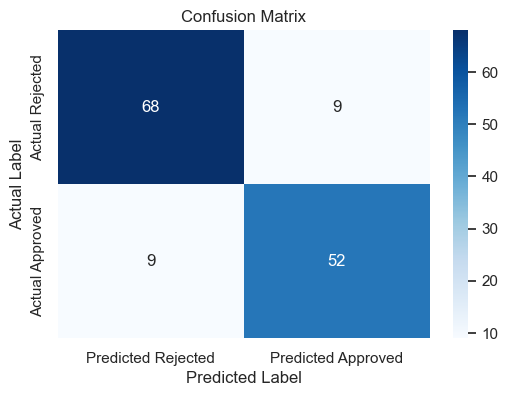

In [20]:
 # Visualize confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Rejected", "Predicted Approved"],
    yticklabels=["Actual Rejected", "Actual Approved"]
  )

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [21]:
# Extract transformed feature names from the preprocessing step
feature_names = model.named_steps[
    "preprocessor"
].get_feature_names_out()

feature_names

array(['num__A2', 'num__A3', 'num__A8', 'num__A11', 'num__A14',
       'num__A15', 'cat__A1_a', 'cat__A1_b', 'cat__A4_l', 'cat__A4_u',
       'cat__A4_y', 'cat__A5_g', 'cat__A5_gg', 'cat__A5_p', 'cat__A6_aa',
       'cat__A6_c', 'cat__A6_cc', 'cat__A6_d', 'cat__A6_e', 'cat__A6_ff',
       'cat__A6_i', 'cat__A6_j', 'cat__A6_k', 'cat__A6_m', 'cat__A6_q',
       'cat__A6_r', 'cat__A6_w', 'cat__A6_x', 'cat__A7_bb', 'cat__A7_dd',
       'cat__A7_ff', 'cat__A7_h', 'cat__A7_j', 'cat__A7_n', 'cat__A7_o',
       'cat__A7_v', 'cat__A7_z', 'cat__A9_f', 'cat__A9_t', 'cat__A10_f',
       'cat__A10_t', 'cat__A12_f', 'cat__A12_t', 'cat__A13_g',
       'cat__A13_p', 'cat__A13_s'], dtype=object)

In [22]:
# Extract logistic regression coefficients
coefficients = model.named_steps[
    "classifier"
].coef_[0]

coefficients

array([ 0.03855005, -0.04660207,  0.28100725,  0.57980772, -0.28275554,
        1.48798255,  0.04458717, -0.04213839,  0.56834951, -0.11248996,
       -0.45341078, -0.11248996,  0.56834951, -0.45341078, -0.38332573,
        0.22770412,  0.87334153,  0.29199239, -0.09216111, -1.16349004,
       -0.64486923, -0.47753998, -0.3815491 , -0.02082419,  0.21125886,
       -0.04078957,  0.23491136,  1.36778948, -0.01990451, -0.11185264,
       -0.54748001,  0.14396172,  0.32386892,  0.82523254, -0.06046728,
       -0.02444802, -0.52646193, -1.44772236,  1.45017113, -0.39251534,
        0.39496411,  0.16416368, -0.16171491, -0.63377323,  1.00124693,
       -0.36502492])

In [23]:
# Convert coefficients from log-odds into odds ratios
odds_ratios = np.exp(coefficients)

odds_ratios

array([1.03930275, 0.95446713, 1.32446321, 1.78569504, 0.75370402,
       4.42815294, 1.04559611, 0.95873709, 1.76535095, 0.89360632,
       0.63545705, 0.89360632, 1.76535095, 0.63545705, 0.68159085,
       1.25571372, 2.39490012, 1.33909282, 0.91195821, 0.31239401,
       0.52473116, 0.62030749, 0.68280286, 0.97939113, 1.23523207,
       0.96003112, 1.26479666, 3.92666112, 0.98029227, 0.89417601,
       0.57840555, 1.1548399 , 1.38246608, 2.28241145, 0.94132456,
       0.97584842, 0.59069118, 0.23510516, 4.26384414, 0.67535599,
       1.48433092, 1.17840719, 0.85068369, 0.53058599, 2.72167345,
       0.69417935])

In [24]:
# Create a DataFrame to organize features, coefficients, and odds ratios
odds_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Odds Ratio": odds_ratios
})

odds_df.head()

,Feature,Coefficient,Odds Ratio
0,num__A2,0.038550,1.039303
1,num__A3,-0.046602,0.954467
2,num__A8,0.281007,1.324463
3,num__A11,0.579808,1.785695
4,num__A14,-0.282756,0.753704


In [25]:
# Show the top features that increase the odds of credit approval
odds_df.sort_values(
    by="Odds Ratio",
    ascending=False
).head(10)

,Feature,Coefficient,Odds Ratio
5,num__A15,1.487983,4.428153
38,cat__A9_t,1.450171,4.263844
27,cat__A6_x,1.367789,3.926661
44,cat__A13_p,1.001247,2.721673
16,cat__A6_cc,0.873342,2.394900
33,cat__A7_n,0.825233,2.282411
3,num__A11,0.579808,1.785695
12,cat__A5_gg,0.568350,1.765351
8,cat__A4_l,0.568350,1.765351
40,cat__A10_t,0.394964,1.484331


In [26]:
# Show the top features that decrease the odds of credit approval
odds_df.sort_values(
    by="Odds Ratio",
    ascending=True
).head(10)

,Feature,Coefficient,Odds Ratio
37,cat__A9_f,-1.447722,0.235105
19,cat__A6_ff,-1.163490,0.312394
20,cat__A6_i,-0.644869,0.524731
43,cat__A13_g,-0.633773,0.530586
30,cat__A7_ff,-0.547480,0.578406
36,cat__A7_z,-0.526462,0.590691
21,cat__A6_j,-0.477540,0.620307
13,cat__A5_p,-0.453411,0.635457
10,cat__A4_y,-0.453411,0.635457
39,cat__A10_f,-0.392515,0.675356


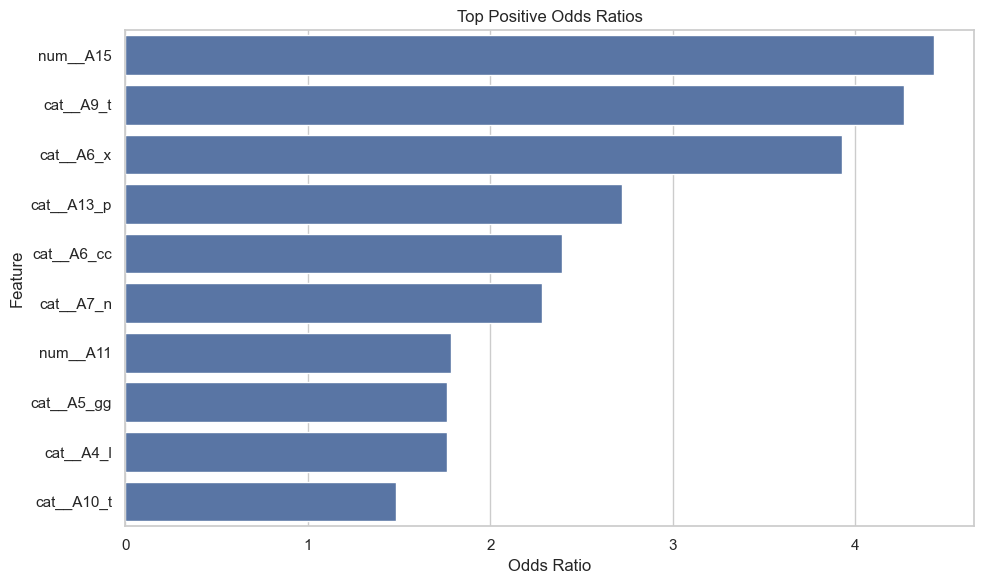

In [27]:
# Visualize the top positive odds ratios
top_features = odds_df.sort_values(
    by="Odds Ratio",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Odds Ratio",
    y="Feature"
)

plt.title("Top Positive Odds Ratios")
plt.tight_layout()
plt.show()